### Importing necessary libraries ###

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Loading Dataset ###

In [2]:
df = pd.read_csv("data/titanic.csv")

### Understanding Data ###

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.shape

(891, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

# Checking null values, duplicates, handling them and dropping unnecessary column: #
- Embarked is a categorical feature so mode is the most appropriate choice.
- Cabin has approx 70-80% null values so it had better to be dropped.
- Age has outliers so it had better to be filled with median.
- Ticket and Passenger_id should be dropped as they are useless and all different values

In [8]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df = df.drop(columns = "Cabin")
df["Age"] = df["Age"].fillna(df["Age"].median())
df = df.drop(columns = ["Ticket", "PassengerId"])

In [9]:
df.duplicated().any()

np.False_

In [10]:
df.isna().any()

Survived    False
Pclass      False
Name        False
Sex         False
Age         False
SibSp       False
Parch       False
Fare        False
Embarked    False
dtype: bool

### Survival Distribution

**Observation:** Majority of passengers did not survive. The number of non-survivors is higher than survivors.

**Insight:** The dataset is imbalanced, which may affect model performance. Special attention may be needed while training the model.

<Axes: xlabel='Survived', ylabel='count'>

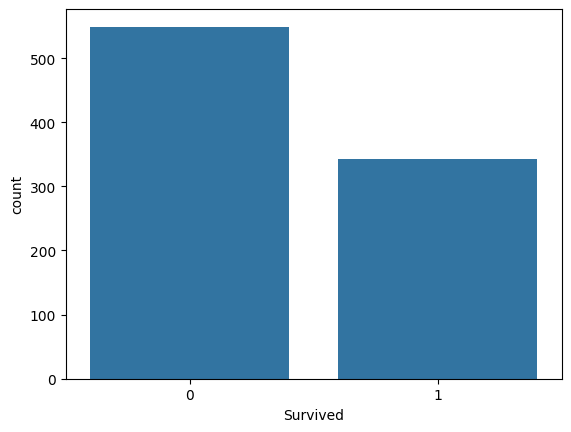

In [11]:
sns.countplot(
    data = df, 
    x = "Survived"
)

### Gender vs Survival

**Observation:** Female passengers have a much higher survival rate compared to males.

**Insight:** Gender is a strong feature affecting survival and should be important for prediction models.

<Axes: xlabel='Sex', ylabel='count'>

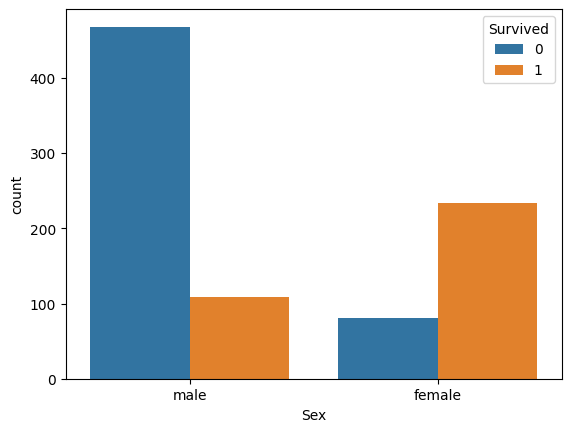

In [12]:
sns.countplot(
    x="Sex", 
    hue="Survived", 
    data=df
)

### Passenger class vs Survival

**Observation:** Higher class passengers have a higher survival rate compared to Lower class passengers.

**Insight:** Socio-economic status is a strong feature affecting survival and should be considered.

<Axes: xlabel='Pclass', ylabel='count'>

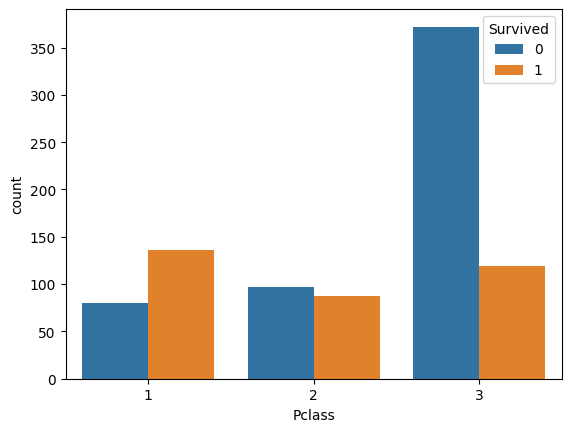

In [13]:
sns.countplot(
    x="Pclass", 
    hue="Survived", 
    data=df
)

### Age Distribution

**Observation:** Most passengers are between 20–40 years old. Some extreme values are also present.

**Insight:** Presence of outliers suggests that median is a better choice for handling missing values.

<Axes: xlabel='Age', ylabel='Count'>

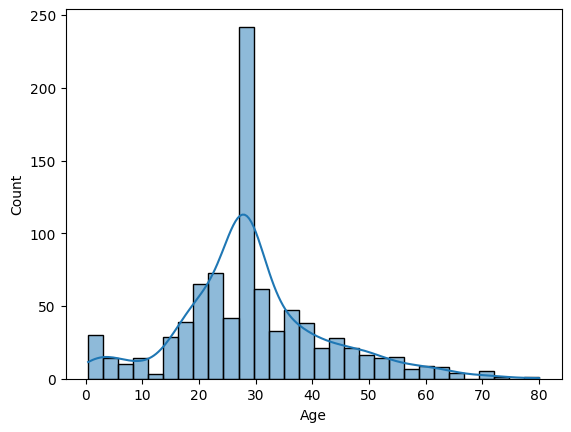

In [14]:
sns.histplot(
    df["Age"], 
    kde=True
)

### Embarked Port Analysis

**Observation:** Most passengers boarded from Southampton.

**Insight:** Since Embarked is categorical and dominated by one category, missing values can be filled using mode.

<Axes: xlabel='Embarked', ylabel='count'>

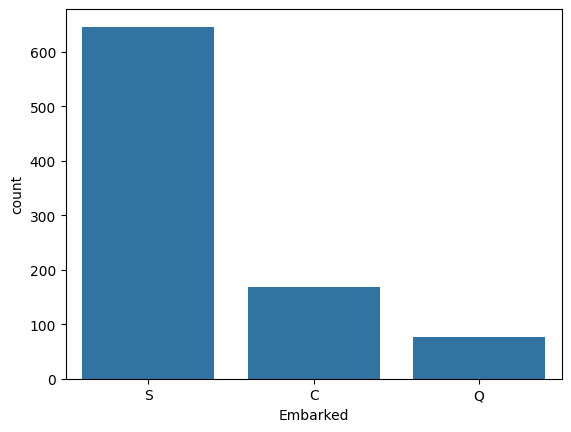

In [15]:
sns.countplot(
    data = df,
    x = "Embarked"
)

### Age vs Survival

**Observation:** Young children and adults have a higher survival rate compared to Senior citizens or old people.

**Insight:** Age is a strong feature affecting survival and should be considered in the model.

<Axes: xlabel='Age', ylabel='Count'>

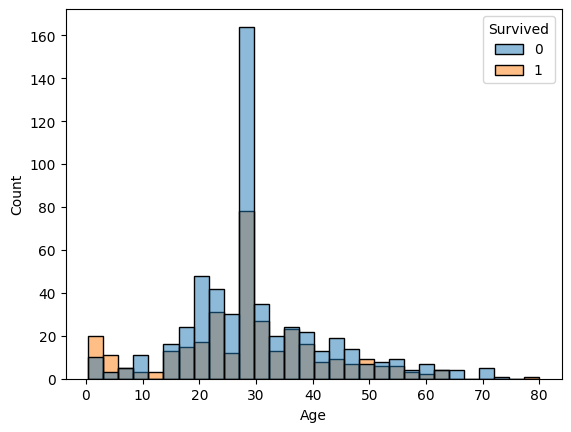

In [16]:
sns.histplot(
    data=df, 
    x="Age", 
    hue="Survived", 
    bins=30
)

In [17]:
df["Sex"] = df["Sex"].apply(lambda x : 1 if x == "male" else 0)
df = pd.get_dummies(df, columns=["Embarked"])
df["Family_size"] = df["SibSp"] +df["Parch"] + 1

In [18]:
df[["Last_name", "First_name"]] = df["Name"].str.split(",", expand = True)
df["Title"] = df["First_name"].str.split(".").str[0].str.strip()
df["Is_rare"] = df["Title"].apply(lambda x : 1 if x in ["Dr", "Rev", "Col", "Mlle", "Major", "Ms", "Mme", "Don", "Lady", "Sir", "Capt", "the Countess", "Jonkheer"] else 0)

## Feature Engineering

- Converted Sex column into numeric values
- Applied one-hot encoding to Embarked
- Created a new feature FamilySize
- Extracted Title from Name to capture social status
- Created a column Is_rare for rare personalities on Titanic

In [19]:
df = df.drop(columns = ["Name", "First_name", "Last_name", "Title"])

### Dropped Unnecessary columns which would help nothing in model ###

In [20]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Family_size,Is_rare
0,0,3,1,22.0,1,0,7.2500,False,False,True,2,0
1,1,1,0,38.0,1,0,71.2833,True,False,False,2,0
2,1,3,0,26.0,0,0,7.9250,False,False,True,1,0
3,1,1,0,35.0,1,0,53.1000,False,False,True,2,0
4,0,3,1,35.0,0,0,8.0500,False,False,True,1,0


In [21]:
df.isna().any()

Survived       False
Pclass         False
Sex            False
Age            False
SibSp          False
Parch          False
Fare           False
Embarked_C     False
Embarked_Q     False
Embarked_S     False
Family_size    False
Is_rare        False
dtype: bool

### Our data is ready to be trained as all columns are numeric and have no null values ###

In [22]:
y = df["Survived"]
X = df.drop(columns = "Survived")

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

## Data Preparation

- Split the dataset into features (X) and target (y)
- Performed train-test split to evaluate model performance on unseen data

In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Feature Scaling

- Applied StandardScaler for Logistic Regression as it is sensitive to feature scaling
- Random Forest does not require scaling as it is a tree-based model

In [25]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter = 1000)
lr_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Model Building and Training

Two models were used:
- Logistic Regression (baseline model)
- Random Forest (to improve performance)

Models were trained:
- rf_model with mormal data
- lr_model with scaled data

In [27]:
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test)

In [28]:
from sklearn.metrics import accuracy_score

print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))

Logistic Regression: 0.7988826815642458
Random Forest: 0.8324022346368715


In [29]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred_lr))

[[89 16]
 [20 54]]


In [30]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred_rf))

[[91 14]
 [16 58]]


## Model Evaluation

- Evaluated models using accuracy score and confusion matrix
- Compared performance of Logistic Regression and Random Forest

## Results

- Logistic Regression Accuracy: 83%
- Random Forest Accuracy: 80%
- Random Forest performed better due to its ability to handle complex patterns

## Conclusion

- The model achieved an accuracy of 83%
- Random Forest performed better than Logistic Regression
- Key factors affecting survival were Gender, Passenger Class, and Fare
- Feature engineering (Is_rare and FamilySize) improved performance